In [1]:
%reload_ext autoreload
%autoreload 2

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from types import SimpleNamespace

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

## 1. Problem Definition

### 1.1 Mesh

In [4]:
from mesher import Mesh2D

mesh = Mesh2D.from_salome_med(filepath='../meshes/Cantilever.med')

Loaded SALOME .med mesh: 459 nodes, 516 elements
Node groups (4): ['left', 'right', 'top', 'bottom']
Element groups (5): ['all', 'bottom', 'top', 'right', 'left']


### 1.2 Boundary Conditions

In [5]:
from conditions import BoundaryCondition

bcs = {
    'left': [BoundaryCondition(dof=1, value=0.0),
             BoundaryCondition(dof=2, value=0.0)]
}

### 1.3 Applied Loads

In [6]:
from solver import LineLoad

traction = {
    'top': LineLoad(fx=0.0, fy=-2.0e-1, reference='global'),
}

## 2. Material Models

### 2.1 Micro-scale Phases

In [7]:
from materials import NLElasticMatrix, LinearElastic

# Shared material parameters
Km, alpha1, alpha2 = 4780.0, 50.0, 0.06     # Soft matrix (NLElasticMatrix)
Kf, Gf             = 43500.0, 29900.0        # Hard inclusion (isotropic linear elastic)

E_hard  = (9.0 * Kf * Gf) / (3.0 * Kf + Gf)
nu_hard = (3.0 * Kf - 2.0 * Gf) / (2.0 * (3.0 * Kf + Gf))

soft = NLElasticMatrix(Km=Km, alpha1=alpha1, alpha2=alpha2)
hard = LinearElastic(emod=E_hard, nu=nu_hard)

print(f"Soft:  NLElasticMatrix  Km={Km}, alpha1={alpha1}, alpha2={alpha2}")
print(f"Hard:  LinearElastic    E={E_hard:.1f}, nu={nu_hard:.4f}")

Soft:  NLElasticMatrix  Km=4780.0, alpha1=50.0, alpha2=0.06
Hard:  LinearElastic    E=72979.1, nu=0.2204


### 2.2 Microestructures pool

In [8]:
from microstructures import RandomBlocks, MicrostructurePool

# Parameters
fhard_min, fhard_max, nbins = 0.30, 0.40, 8
fhard_bins = torch.linspace(fhard_min, fhard_max, nbins)
rve_lx, rve_ly = 0.10, 0.10

pool = MicrostructurePool(
    generator=RandomBlocks(resolution=96, n_blocks=8),
    fhard_bins=fhard_bins,
    nmicro=4,
    meshing=True,
    delta_x=rve_lx,
    delta_y=rve_ly,
    device='cpu',
    dtype=torch.float32,
)

Building MicrostructurePool: 8 bins × 4 variants = 32 microstructures...
   →   5/32 microstructures generated
   →  10/32 microstructures generated
   →  15/32 microstructures generated
   →  20/32 microstructures generated
   →  25/32 microstructures generated
   →  30/32 microstructures generated
   →  32/32 microstructures generated
MicrostructurePool ready | Shape: torch.Size([32, 1, 96, 96])


In [ ]:
pool.plot(max_cols=4)

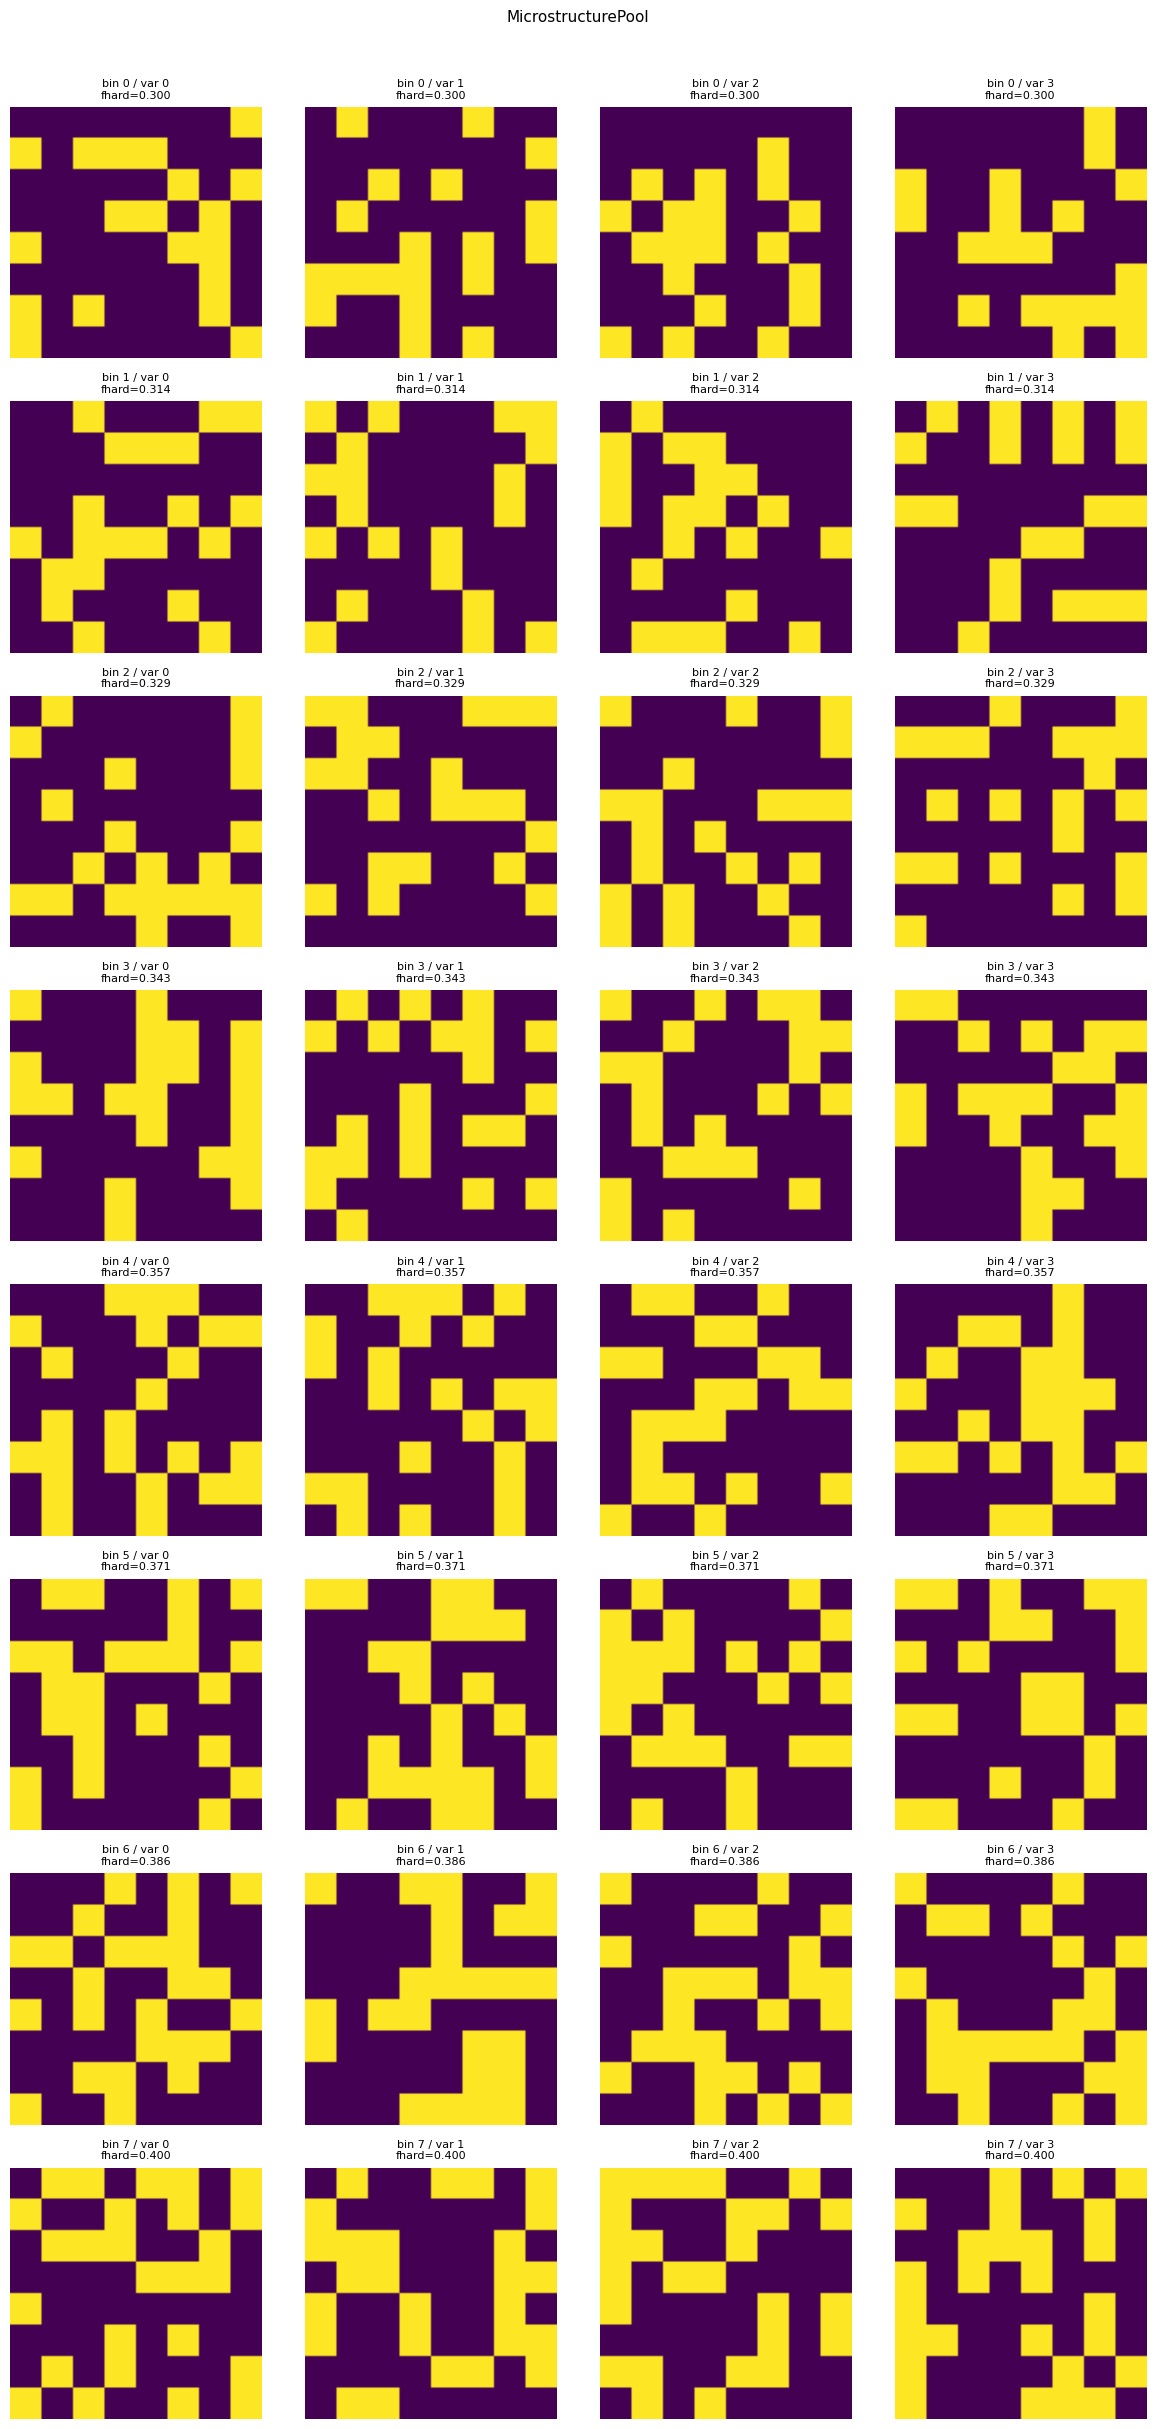

### 2.3 FNO Surrogate

In [9]:
# Define a function for variation of fhard across the domain
def fhard_linear(coords):
    """Linear variation: fhard_max at x=0 decreasing to fhard_min at x=xmax."""
    x = coords[..., 0]
    return fhard_max - (fhard_max - fhard_min) * x / x.max()

In [10]:
from rve_analyzer import load_trained_model
from materials import FNOmat

# Load trained surrogate model
model, normalizers = load_trained_model(
    checkpoint_dir="../RVEs/checkpoints", model_name_prefix="rve2_fno_v10"
)
model.to(device)

# FNO material
rve2_fno = FNOmat(
    model=model,
    normalizers=normalizers,
    microstructure_pool=pool,
    fhard=fhard_linear,
    chunk_size=64,
    dtype=torch.float32,
    device=device,
    seed=42,
)
print(f"FNOmat ready | device: {device}")

FNOmat ready | device: cuda


### 2.4 FEM² Full-field Homogenization

In [11]:
from materials import FEMmat

nelem_rve = pool.pool_phase.shape[2] // 2   # 96/2 = 48 elements per side
print(f"FEM pool: {pool.num_bins} bins × {pool.nmicro} variants "
      f"= {len(pool.meshes)} meshes  |  RVE: {nelem_rve}×{nelem_rve} Q4  "
      f"({rve_lx}×{rve_ly})")

rve2_fem = FEMmat(
    soft=NLElasticMatrix(Km=Km, alpha1=alpha1, alpha2=alpha2,
                         dtype=torch.float64, device='cpu'),
    hard=LinearElastic(emod=E_hard, nu=nu_hard,
                       dtype=torch.float64, device='cpu'),
    microstructure_pool=pool,
    fhard=fhard_linear,
    n_state=3,
    dtype=torch.float64,
    device='cpu',
    exact_integration=False,   # uniform voxelized mesh -> mean is exact
    fd_scheme='central',
    seed=42,
)
print(f"FEMmat ready | RVE: {nelem_rve}×{nelem_rve} Q4 ({rve_lx}×{rve_ly}) | "
      f"fd_scheme='{rve2_fem.fd_scheme}'")

FEM pool: 8 bins × 4 variants = 32 meshes  |  RVE: 48×48 Q4  (0.1×0.1)
FEMmat ready | RVE: 48×48 Q4 (0.1×0.1) | fd_scheme='central'


## 3. Macro FEM Solves

### 3.1 FNO Surrogate

In [16]:
from solver import NFEA

formulation = 'TLF'
ftol = 1e-3

fem_solver_fno = NFEA(
    mesh=mesh, bcs=bcs,
    matfld={'all': rve2_fno},
    line_loads=traction,
    verbose=True, device=device,
    formulation = formulation,
)

fem_solver_fno.ftol = ftol

[matfld] Assigned: ['all']
[matfld] All 400 quad elements have assigned material
[line_load] Applied 1 line load groups
[BC] Processed 2 Dirichlet condition(s) → 18 total constraint(s)
[BC] Applied Dirichlet BCs → 18 fixed DOFs


### 3.1.1 RVE field

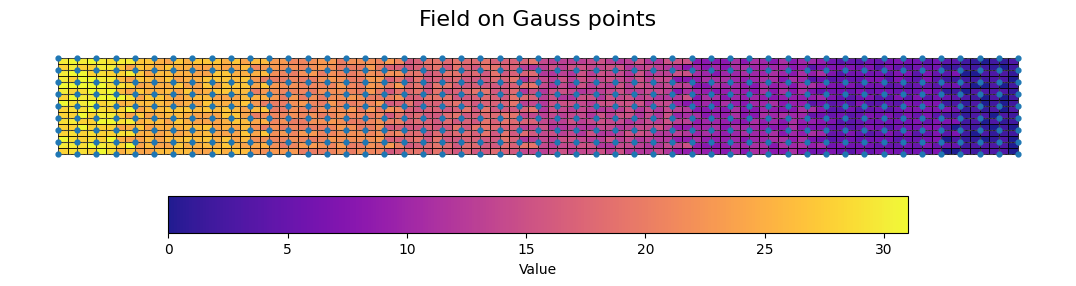

In [17]:
field = fem_solver_fno.quad_batches['all'].state[:, :, 0]   # (nelem, ngauss)
fem_solver_fno.plot_field(field, show_nodes=True, cmap='plasma')

### 3.1.2 Run

In [18]:
torch.cuda.empty_cache()
t0 = time.time()
fem_solver_fno.run_complete(nsteps=1)
dt = time.time() - t0
_ux = fem_solver_fno.udisp[2*(_nid-1)].item()
_uy = fem_solver_fno.udisp[2*(_nid-1) + 1].item()
print(f"[FNO   ] Node@(10,0.5): ux={_ux:.6f}  uy={_uy:.6f}  |  {dt:.1f}s")

[Load] Set load factor = 1.0000.
Iter   1 | du error: 1.00e+00  Res error: 1.62e+02  Energetic error: -1.37e+00
Iter   2 | du error: 3.99e-02  Res error: 1.15e+00  Energetic error: 1.90e-03
Iter   3 | du error: 6.12e-02  Res error: 8.52e-01  Energetic error: -9.90e-06
Iter   4 | du error: 9.08e-04  Res error: 7.03e-03  Energetic error: 1.21e-08
Iter   5 | du error: 2.49e-05  Res error: 1.35e-03  Energetic error: -1.59e-11
Iter   6 | du error: 2.96e-07  Res error: 8.23e-04  Energetic error: -3.39e-12
Converged in 6 iterations
[FNO   ] Node@(10,0.5): ux=-0.015042  uy=-0.509941  |  157.1s


### 3.1.3 Deformed

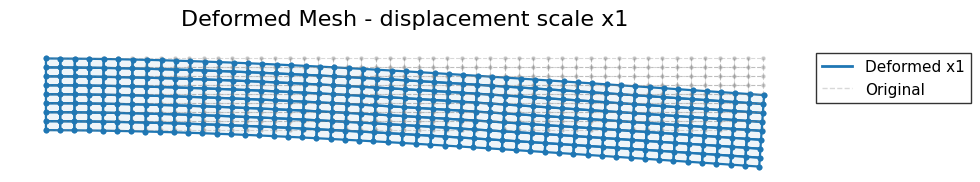

In [19]:
fem_solver_fno.plot_deformed_mesh(scale=1)

### 3.2 FEM² Full-field


In [24]:
fem_solver_fem = NFEA(
    mesh=mesh, bcs=bcs,
    matfld={'all': rve2_fem},
    line_loads=traction,
    verbose=True,
    device='cpu',   # must match rve2_fem.device
    formulation = formulation,
)

fem_solver_fem.ftol = ftol

[matfld] Assigned: ['all']
[matfld] All 400 quad elements have assigned material
[line_load] Applied 1 line load groups
[BC] Processed 2 Dirichlet condition(s) → 18 total constraint(s)
[BC] Applied Dirichlet BCs → 18 fixed DOFs


### 3.2.1 RVE field

In [25]:
# ── Tag check: FNO vs FEM² must use the same microstructure at every GP ──
tags_fno_all = fem_solver_fno.quad_batches['all'].state[:, :, 0].cpu().round().long()
tags_fem_all = fem_solver_fem.quad_batches['all'].state[:, :, 0].cpu().round().long()

n_total    = tags_fno_all.numel()
n_mismatch = (tags_fno_all != tags_fem_all).sum().item()

print(f"Tag check — FNO vs FEM²  ({n_total} GPs total):")
print(f"  Mismatches : {n_mismatch} / {n_total}")
if n_mismatch == 0:
    print("  OK — all tags match.")
else:
    print(f"  WARNING — {n_mismatch} GPs have different microstructures.")
    print("  Fix: both FNOmat and FEMmat must use device='cpu' in Generator (init_state).")
    ids     = fem_solver_fno.quad_batches['all'].ids.cpu()
    bad_mask = (tags_fno_all != tags_fem_all).any(dim=1)
    print(f"  First mismatching element IDs: {ids[bad_mask][:5].tolist()}")

Tag check — FNO vs FEM²  (1600 GPs total):
  Mismatches : 0 / 1600
  OK — all tags match.


### 3.2.3 Run

In [26]:
print("[FE2] Starting solve  (this will take a long time)...")
t0 = time.time()
fem_solver_fem.run_complete(nsteps=1)
dt = time.time() - t0
print(f"\n[FE2] Total: {dt:.1f}s  ({dt/60:.1f} min)")
_ux = fem_solver_fem.udisp[2*(_nid-1)].item()
_uy = fem_solver_fem.udisp[2*(_nid-1) + 1].item()
print(f"[FEM2  ] Node@(10,0.5): ux={_ux:.6f}  uy={_uy:.6f}")

[FE2] Starting solve  (this will take a long time)...
[Load] Set load factor = 1.0000.
Iter   1 | du error: 1.00e+00  Res error: 1.67e+02  Energetic error: -1.29e+00
Iter   2 | du error: 4.00e-02  Res error: 5.25e-01  Energetic error: -1.04e-04
Iter   3 | du error: 7.26e-02  Res error: 1.33e+00  Energetic error: -8.93e-05
Iter   4 | du error: 1.73e-04  Res error: 5.80e-05  Energetic error: 8.40e-10
Iter   5 | du error: 7.51e-07  Res error: 5.84e-07  Energetic error: 4.79e-17
Converged in 5 iterations

[FE2] Total: 78592.6s  (1309.9 min)
[FEM2  ] Node@(10,0.5): ux=-0.015657  uy=-0.522844


### 3.2.3 Deformed

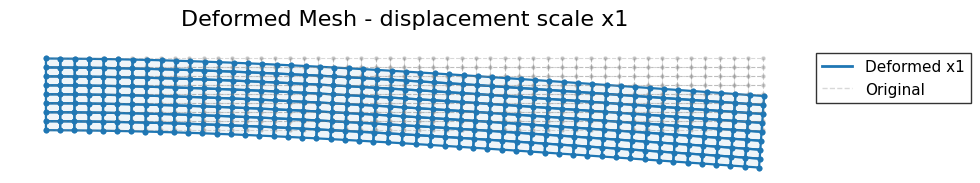

||u_FNO - u_FEM2|| / ||u_FEM2|| = 2.238%


In [27]:
fem_solver_fem.plot_deformed_mesh(scale=1)

u_fem2 = fem_solver_fem.udisp.cpu()
u_fno  = fem_solver_fno.udisp.cpu().double()
err_rel = (u_fem2 - u_fno).norm() / (u_fem2.norm() + 1e-12)
print(f"||u_FNO - u_FEM2|| / ||u_FEM2|| = {err_rel:.3%}")

### 3.3 Stress Fields

In [ ]:
comp_labels = [r'$\sigma_{xx}$', r'$\sigma_{yy}$', r'$\tau_{xy}$']

sigma_fem   = fem_solver_fem.compute_stresses()    # (nelem, ngauss, 3) — slow: re-runs all RVE solves
sigma_fno   = fem_solver_fno.compute_stresses()    # (nelem, ngauss, 3) — fast (GPU FNO)

### 3.4 Von Mises Stress and Spatial Error Field (FNO vs FEM²)

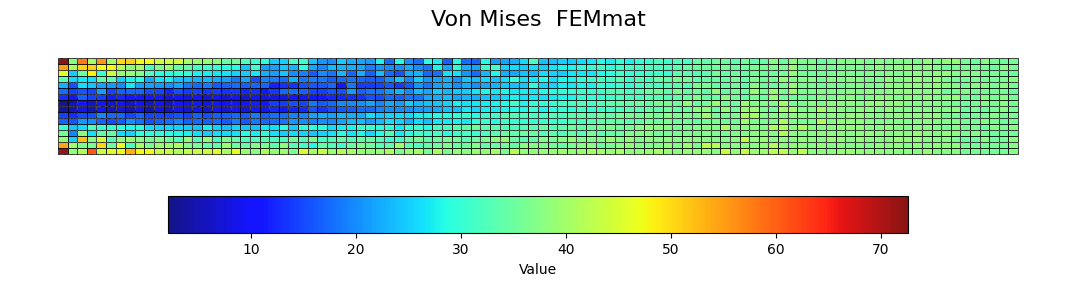

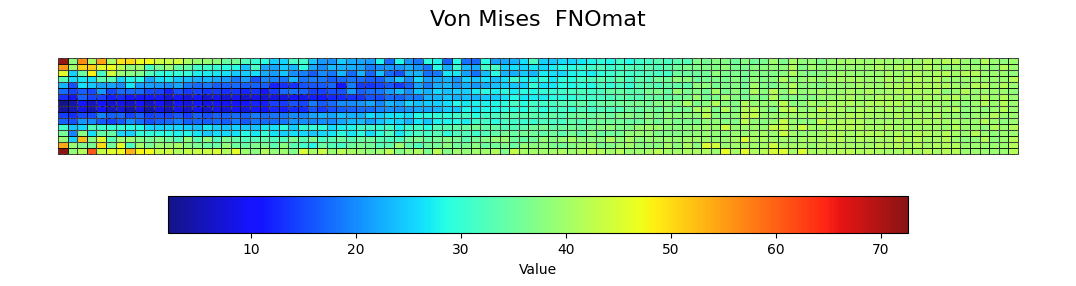

Relative error field — FNO vs FEM²
  mean : 4.21%
  max  : 10.94%
  median: 3.64%


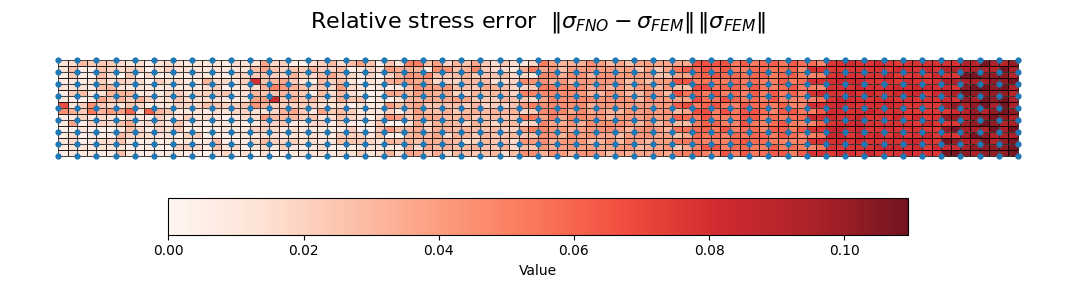

In [ ]:
def von_mises(sigma):
    """sigma: (nelem, ngauss, 3) → (nelem, ngauss) Von Mises stress."""
    sxx, syy, sxy = sigma[..., 0], sigma[..., 1], sigma[..., 2]
    return torch.sqrt(sxx**2 - sxx * syy + syy**2 + 3.0 * sxy**2)

# ── Von Mises ─────────────────────────────────────────────────────────────
vm_fno   = von_mises(sigma_fno.float())
vm_fem   = von_mises(sigma_fem.float())

vmin_vm = min(vm_fno.min(), vm_fem.min()).item()
vmax_vm = max(vm_fno.max(), vm_fem.max()).item()

for solver, vm, lbl in [
    (fem_solver_fem,   vm_fem,   'FEMmat'),
    (fem_solver_fno,   vm_fno,   'FNOmat'),
]:
    solver.plot_field(vm, title=f'Von Mises  {lbl}', show_nodes=False, vmin=vmin_vm, vmax=vmax_vm)

# ── Relative error field (FNO vs FEM²) ────────────────────────────────────
# ||σ_FNO - σ_FEM||_2 / (||σ_FEM||_2 + ε)  per Gauss point
eps = 1e-12
diff  = sigma_fno.float() - sigma_fem.float()            # (nelem, ngauss, 3)
err_field = diff.norm(dim=-1) / (sigma_fem.float().norm(dim=-1) + eps)  # (nelem, ngauss)

print(f"Relative error field — FNO vs FEM²")
print(f"  mean : {err_field.mean().item():.2%}")
print(f"  max  : {err_field.max().item():.2%}")
print(f"  median: {err_field.median().item():.2%}")

fem_solver_fno.plot_field(
    err_field,
    title=r'Relative stress error  $\|σ_{FNO} - σ_{FEM}\| \/ \|σ_{FEM}\|$',
    cmap='Reds',
    vmin=0.0,
)


## 4. Element Inspection: Gauss Points and Micro-mechanical Field

Element ID      : 1  (0-based index in conn: 0)
Nodes (1-based) : [  1   5 117 116]
Centroid        : (0.1000, 0.9375)


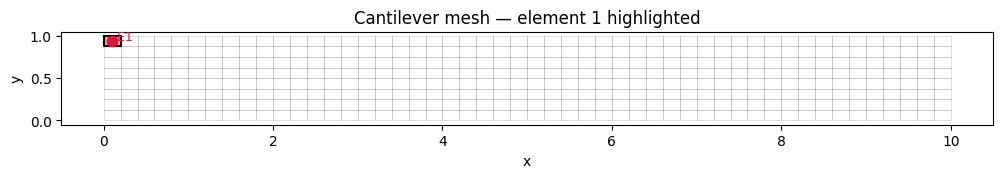

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# Element selection and mesh visualization
# ═══════════════════════════════════════════════════════════════════════════
ELEM_ID = 1   # change to the desired element (1-based)

coords  = mesh.coordinates              # (nnod, 2)  numpy array
conn    = mesh.elements['quad']         # list of node-lists (1-based)
all_ids = list(mesh.element_groups['all'])

elem_idx = all_ids.index(ELEM_ID)       # 0-based position in conn[]
nodes_1b = conn[elem_idx]
nodes_0b = [n - 1 for n in nodes_1b]
ec       = coords[nodes_0b]             # (nnode, 2) corner coords
centroid = ec.mean(axis=0)

print(f"Element ID      : {ELEM_ID}  (0-based index in conn: {elem_idx})")
print(f"Nodes (1-based) : {nodes_1b}")
print(f"Centroid        : ({centroid[0]:.4f}, {centroid[1]:.4f})")

fig, ax = plt.subplots(figsize=(10, 4))

for nds in conn:
    pts = coords[[n - 1 for n in nds]]
    pts_c = np.vstack([pts, pts[0]])
    ax.plot(pts_c[:, 0], pts_c[:, 1], color='gray', lw=0.4, alpha=0.45)

ax.fill(ec[:, 0], ec[:, 1], color='tomato', alpha=0.55, zorder=3)
ax.plot(np.append(ec[:, 0], ec[0, 0]),
        np.append(ec[:, 1], ec[0, 1]), 'k-', lw=1.5, zorder=4)
ax.scatter(*centroid, color='crimson', s=55, zorder=5)
ax.text(centroid[0] + 0.005, centroid[1] + 0.005,
        f' E{ELEM_ID}', fontsize=9, color='crimson', zorder=6)

ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Cantilever mesh — element {ELEM_ID} highlighted', fontsize=12)
plt.tight_layout()
plt.show()


In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# Homogenized stresses at element Gauss points (FEMmat vs FNOmat)
# ═══════════════════════════════════════════════════════════════════════════
batch_fno = fem_solver_fno.quad_batches['all']
batch_fem = fem_solver_fem.quad_batches['all']

idx_fno = (batch_fno.ids.cpu() == ELEM_ID).nonzero(as_tuple=True)[0].item()
idx_fem = (batch_fem.ids.cpu() == ELEM_ID).nonzero(as_tuple=True)[0].item()

# Strains at Gauss points (from each solver's own converged displacement field)
u_loc_fno = batch_fno.get_local_disp(fem_solver_fno.udisp)   # (nelem, nnode, 2)
u_loc_fem = batch_fem.get_local_disp(fem_solver_fem.udisp)

eps_fno = batch_fno.compute_infinitesimal_strain(u_loc_fno)   # (nelem, ngp, 3)
eps_fem = batch_fem.compute_infinitesimal_strain(u_loc_fem)

ngp = eps_fno.shape[1]
print(f"Gauss points per element: {ngp}")

# FNOmat stresses (forward pass only)
state_fno_e  = batch_fno.state[idx_fno:idx_fno+1]   # (1, ngp, n_state)
strain_fno_e = eps_fno[idx_fno:idx_fno+1]            # (1, ngp, 3)
with torch.no_grad():
    sigma_fno_e, _, _ = rve2_fno.update_state(
        strain_fno_e.to(device=device, dtype=torch.float32),
        state_fno_e.to(device=device, dtype=torch.float32),
        isTangent=False,
    )
sigma_fno_e = sigma_fno_e[0].cpu().double()   # (ngp, 3)

# FEMmat stresses (each GP runs one full RVE solve ≈ 7–9 s)
state_fem_e  = batch_fem.state[idx_fem:idx_fem+1]
strain_fem_e = eps_fem[idx_fem:idx_fem+1]
print(f"Running {ngp} RVE solve(s) for FEMmat — estimated ~{ngp*8} s ...")
t0 = time.time()
sigma_fem_e, _, _ = rve2_fem.update_state(strain_fem_e, state_fem_e, isTangent=False)
sigma_fem_e = sigma_fem_e[0].cpu()   # (ngp, 3)
print(f"Done in {time.time()-t0:.1f} s")

# Print comparison table
SEP = '─' * 72
print(f"\n{'═'*72}")
print(f"  Homogenized stresses — Element {ELEM_ID}   [σxx, σyy, τxy]")
print(f"{'═'*72}")
for g in range(ngp):
    sf = sigma_fem_e[g].double()
    sn = sigma_fno_e[g]
    err = (sn - sf).norm() / (sf.norm() + 1e-12)
    eps_g = eps_fem[idx_fem, g].cpu().numpy()
    print(f"\n  GP {g+1}   ε = [{eps_g[0]:+.4e}  {eps_g[1]:+.4e}  {eps_g[2]:+.4e}]")
    print(SEP)
    print(f"  FEMmat : [{sf[0]:+11.4f}  {sf[1]:+11.4f}  {sf[2]:+11.4f}]")
    print(f"  FNOmat : [{sn[0]:+11.4f}  {sn[1]:+11.4f}  {sn[2]:+11.4f}]")
    diff = sn - sf
    print(f"  Δσ     : [{diff[0]:+11.4f}  {diff[1]:+11.4f}  {diff[2]:+11.4f}]")
    print(f"  err_rel: {err:.2%}")

tags_fno_e = batch_fno.state[idx_fno, :, 0].cpu().tolist()
tags_fem_e = batch_fem.state[idx_fem, :, 0].cpu().tolist()
print(f"\n{'═'*72}")
print(f"  RVE tags (state[...,0])  FNO: {tags_fno_e}  |  FEM: {tags_fem_e}")


Gauss points per element: 4
Running 4 RVE solve(s) for FEMmat — estimated ~32 s ...
Done in 5.3 s

════════════════════════════════════════════════════════════════════════
  Homogenized stresses — Element 1   [σxx, σyy, τxy]
════════════════════════════════════════════════════════════════════════

  GP 1   ε = [+8.0294e-03  -1.3338e-03  -6.8551e-03]
────────────────────────────────────────────────────────────────────────
  FEMmat : [   +81.8285     +44.2266      -8.7260]
  FNOmat : [   +80.6885     +44.3119      -8.7799]
  Δσ     : [    -1.1401      +0.0854      -0.0539]
  err_rel: 1.23%

  GP 2   ε = [+8.0294e-03  -4.9777e-03  -3.9359e-03]
────────────────────────────────────────────────────────────────────────
  FEMmat : [   +38.8847      +5.0822      -5.2893]
  FNOmat : [   +39.3142      +5.4888      -5.6002]
  Δσ     : [    +0.4295      +0.4066      -0.3109]
  err_rel: 1.69%

  GP 3   ε = [+6.2049e-03  -1.3338e-03  -4.5777e-03]
──────────────────────────────────────────────────────

Running RVE FEMmat — GP1  ε=[ 0.00802944 -0.00133377 -0.00685512]  (~7-9 s) ...
RVE done in 1.2 s
FEMmat grid: 96×96 GPs  |  FNO: 96×96  (physical domain: 0.1×0.1)
Tags — FNOmat: 30  |  FEMmat: 30


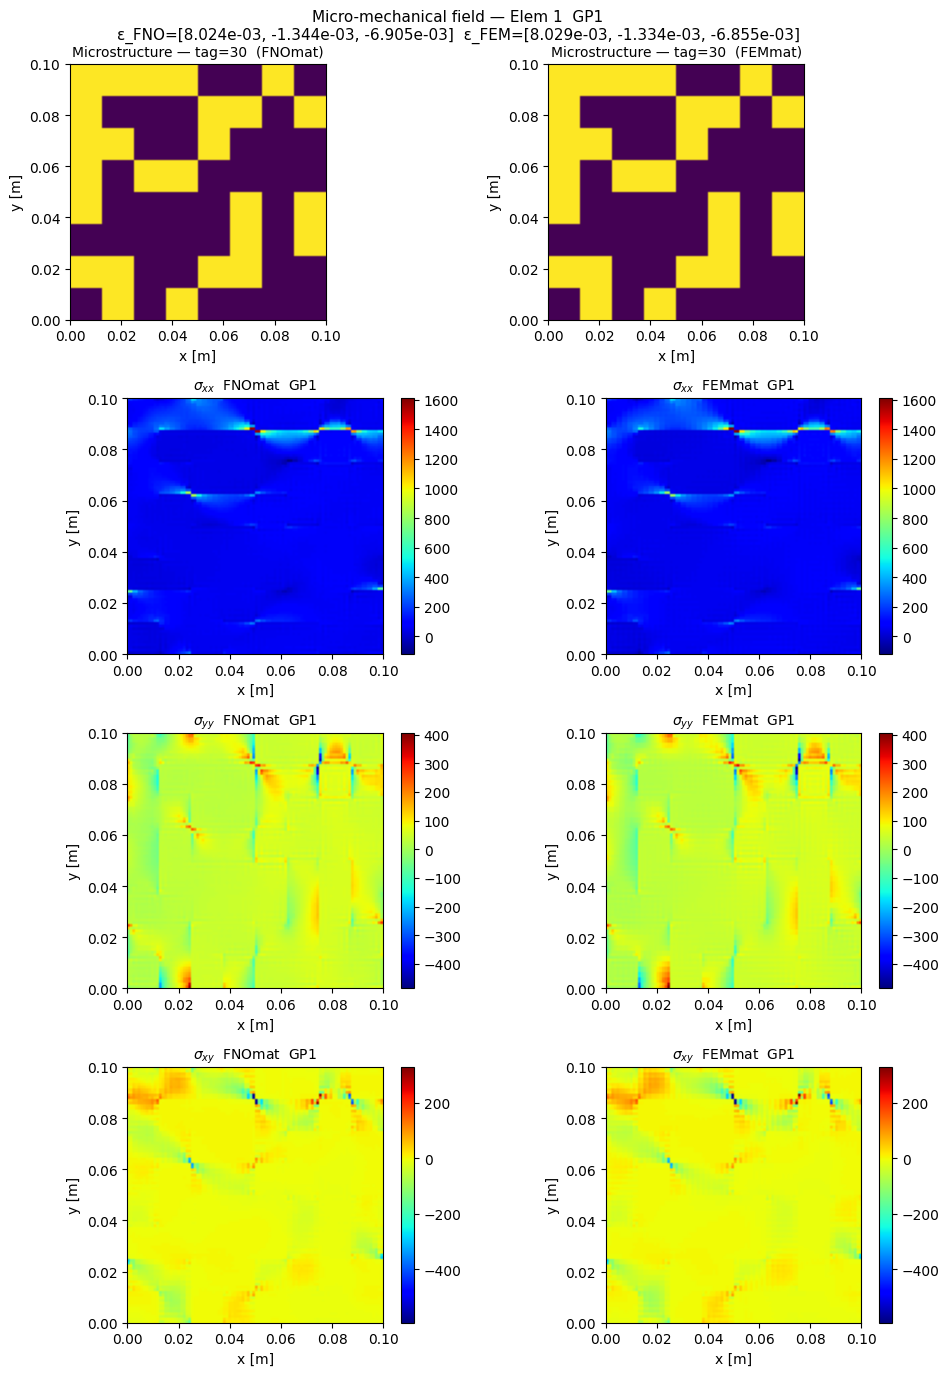


micro-field statistics — GP1  (hom = spatial mean):
Component           FNO hom      FEM hom    err_hom
────────────────────────────────────────────────────
  $\sigma_{xx}$     +80.6886     +81.8285     1.39%
  $\sigma_{yy}$     +44.3120     +44.2266     0.19%
  $\sigma_{xy}$      -8.7799      -8.7260     0.62%


In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# Micro-mechanical field — microstructure + stresses for one GP
#      FNO:    96×96  (= phase field resolution)
#      FEMat: 48×48 elements × 4 GPs (2×2) = 96×96 positions → same res.
#              Each GP is placed at its physical position within the RVE domain
#              using r_gp, s_gp from the batch → 96×96 grid without averaging.
#
# ═══════════════════════════════════════════════════════════════════════════
GP_IDX = 0   # GP to inspect (0 to ngp-1)

comp_labels = [r'$\sigma_{xx}$', r'$\sigma_{yy}$', r'$\sigma_{xy}$']
tag_gp     = int(torch.round(batch_fno.state[idx_fno, GP_IDX, 0]).item())
tag_fem_gp = int(torch.round(batch_fem.state[idx_fem, GP_IDX, 0]).item())
ext = [0, rve_lx, 0, rve_ly]

# ── FNO: micro field predicted by the surrogate  (96×96) ─────────────────
strain_gp_fno = eps_fno[idx_fno, GP_IDX].to(device=device, dtype=torch.float32)

x_local_norm  = rve2_fno.pool_phase_norm[tag_gp:tag_gp+1]
x_global_norm = rve2_fno.g_norm.transform(strain_gp_fno.unsqueeze(0))

with torch.no_grad():
    pred_norm = rve2_fno._inference_in_chunks(x_local_norm, x_global_norm)
    micro_sigma_fno = rve2_fno.y_norm.inverse_transform(pred_norm)[0].cpu().numpy()  # (3, 96, 96)

micro_phase_fno = pool.pool_phase[tag_gp, 0].cpu().numpy()       # (96, 96)
H_fno = micro_sigma_fno.shape[1]   # 96

# ── FEMmat: micro field from RVE solve  (48×48 × 4 GPs → 96×96) ─────────
from conditions import PeriodicBoundaryCondition, BoundaryCondition

strain_gp_fem = eps_fem[idx_fem, GP_IDX].to(dtype=torch.float64)
mesh_rve, lr_pairs, bt_pairs = rve2_fem.pool.meshes[tag_fem_gp]

micro_phase_fem = pool.pool_phase[tag_fem_gp, 0].cpu().numpy()   # (96, 96)

dx_rve = float(mesh_rve.coordinates[:, 0].max() - mesh_rve.coordinates[:, 0].min())
dy_rve = float(mesh_rve.coordinates[:, 1].max() - mesh_rve.coordinates[:, 1].min())

pbc = PeriodicBoundaryCondition(
    exx=strain_gp_fem[0].item(), eyy=strain_gp_fem[1].item(), gxy=strain_gp_fem[2].item(),
    left_right_pairs=lr_pairs, bottom_top_pairs=bt_pairs,
    delta_x=dx_rve, delta_y=dy_rve,
)
bcs_rve = {'fixed_n': [BoundaryCondition(dof=1, value=0.0),
                        BoundaryCondition(dof=2, value=0.0)]}

print(f"Running RVE FEMmat — GP{GP_IDX+1}  ε={strain_gp_fem.numpy()}  (~7-9 s) ...")
t0 = time.time()
rve_solver = NFEA(mesh=mesh_rve, bcs=bcs_rve, matfld=rve2_fem.matfield,
                  mpcs=pbc.get_constraints(), verbose=False, device=rve2_fem.device)
rve_solver.run_complete(nsteps=1)
print(f"RVE done in {time.time()-t0:.1f} s")

# Build 96×96 grid placing each GP at its physical position.
# The batch precomputes r_gp, s_gp (natural coords); the physical position is:
#   x_gp = x_c + r_k * (dx_elem/2),  y_gp = y_c + s_k * (dy_elem/2)
# With 48 elements × 2 GPs per side → 96 positions per axis, same res. as FNO.
coords_rve = mesh_rve.coordinates
N_grid = H_fno                        # = 96
dx_pix = rve_lx / N_grid              # FNO pixel size in x
dy_pix = rve_ly / N_grid              # FNO pixel size in y

micro_sigma_fem = np.zeros((N_grid, N_grid, 3))   # (row=y, col=x, comp)

for b in rve_solver.quad_batches.values():
    ul       = b.get_local_disp(rve_solver.udisp)
    eg       = b.compute_infinitesimal_strain(ul)
    sg, _, _ = b.material.update_state(eg, b.state, isTangent=False)
    sg_np    = sg.cpu().numpy()                    # (nelem_batch, ngp_rve=4, 3)
    nodes_0b = b.nodes.cpu().numpy() - 1           # (nelem_batch, nnode)
    gp_r     = b.r_gp.cpu().numpy()               # (4,)
    gp_s     = b.s_gp.cpu().numpy()               # (4,)

    for i_elem in range(b.nelem):
        node_xy = coords_rve[nodes_0b[i_elem]]     # (nnode, 2)
        x_c  = node_xy[:, 0].mean()
        y_c  = node_xy[:, 1].mean()
        dx_e = (node_xy[:, 0].max() - node_xy[:, 0].min()) / 2   # half-width
        dy_e = (node_xy[:, 1].max() - node_xy[:, 1].min()) / 2   # half-height

        for k in range(len(gp_r)):
            x_gp = x_c + gp_r[k] * dx_e
            y_gp = y_c + gp_s[k] * dy_e
            col = int(round(x_gp / dx_pix - 0.5))
            row = int(round(y_gp / dy_pix - 0.5))
            col = max(0, min(N_grid - 1, col))
            row = max(0, min(N_grid - 1, row))
            micro_sigma_fem[row, col] = sg_np[i_elem, k]

print(f"FEMmat grid: {N_grid}×{N_grid} GPs  |  FNO: {H_fno}×{H_fno}  "
      f"(physical domain: {rve_lx}×{rve_ly})")
print(f"Tags — FNOmat: {tag_gp}  |  FEMmat: {tag_fem_gp}")

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
kw_phase = dict(cmap='viridis', origin='lower', extent=ext)

# Row 0: microstructure — each model uses its own assigned tag
axes[0, 0].imshow(micro_phase_fno, **kw_phase)
axes[0, 0].set_title(f'Microstructure — tag={tag_gp}  (FNOmat)', fontsize=10)
axes[0, 0].set_xlabel('x [m]'); axes[0, 0].set_ylabel('y [m]')

axes[0, 1].imshow(micro_phase_fem, **kw_phase)
axes[0, 1].set_title(f'Microstructure — tag={tag_fem_gp}  (FEMmat)', fontsize=10)
axes[0, 1].set_xlabel('x [m]'); axes[0, 1].set_ylabel('y [m]')

# Rows 1-3: σxx, σyy, τxy  (shared color scale between models)
for c, lbl in enumerate(comp_labels):
    row = c + 1
    fno_field = micro_sigma_fno[c]           # (96, 96)
    fem_field = micro_sigma_fem[:, :, c]     # (96, 96)

    vmin = min(fno_field.min(), fem_field.min())
    vmax = max(fno_field.max(), fem_field.max())
    kw_s = dict(cmap='jet', origin='lower', extent=ext, vmin=vmin, vmax=vmax)

    im0 = axes[row, 0].imshow(fno_field, **kw_s)
    axes[row, 0].set_title(f'{lbl}  FNOmat  GP{GP_IDX+1}', fontsize=10)
    axes[row, 0].set_xlabel('x [m]'); axes[row, 0].set_ylabel('y [m]')
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

    im1 = axes[row, 1].imshow(fem_field, **kw_s)
    axes[row, 1].set_title(f'{lbl}  FEMmat  GP{GP_IDX+1}', fontsize=10)
    axes[row, 1].set_xlabel('x [m]'); axes[row, 1].set_ylabel('y [m]')
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

e_fno = eps_fno[idx_fno, GP_IDX].cpu().numpy()
e_fem = eps_fem[idx_fem, GP_IDX].cpu().numpy()
fig.suptitle(
    f'Micro-mechanical field — Elem {ELEM_ID}  GP{GP_IDX+1}\n'
    f'ε_FNO=[{e_fno[0]:.3e}, {e_fno[1]:.3e}, {e_fno[2]:.3e}]  '
    f'ε_FEM=[{e_fem[0]:.3e}, {e_fem[1]:.3e}, {e_fem[2]:.3e}]',
    fontsize=11,
)
plt.tight_layout()
plt.show()

# Statistics
print(f"\nmicro-field statistics — GP{GP_IDX+1}  (hom = spatial mean):")
print(f"{'Component':<14} {'FNO hom':>12} {'FEM hom':>12} {'err_hom':>10}")
print('─' * 52)
for c, lbl in enumerate(comp_labels):
    fno_m = micro_sigma_fno[c].mean()
    fem_m = micro_sigma_fem[:, :, c].mean()
    err   = abs(fno_m - fem_m) / (abs(fem_m) + 1e-12)
    print(f"  {lbl:<12} {fno_m:+12.4f} {fem_m:+12.4f} {err:>9.2%}")